In [2]:
# performing linear algebra
import numpy as np

# data processing
import pandas as pd

# visualisation
import matplotlib.pyplot as plt
import math
import seaborn as sns
sns.set_style('darkgrid')

In [3]:
#Importing the dataset
df = pd.read_csv("cancer_dataset.csv")
df

,ID,Outcome,Time,Mean Radius,Mean Texture,Mean Perimeter,Mean Area,Mean Smoothness,Mean Compactness,Mean Concavity,...,Worst Perimeter,Worst Area,Worst Smoothness,Worst Compactness,Worst Concavity,Worst Concave Points,Worst Symmetry,Worst Fractal Dimension,Tumor Size,Lymph Node Status
0,119513,N,31,18.02,27.60,117.50,1013.0,0.09489,0.10360,0.10860,...,139.70,1436.0,0.11950,0.1926,0.3140,0.11700,0.2677,0.08113,5.0,5.0
1,8423,N,61,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,...,184.60,2019.0,0.16220,0.6656,0.7119,0.26540,0.4601,0.11890,3.0,2.0
2,842517,N,116,21.37,17.44,137.50,1373.0,0.08836,0.11890,0.12550,...,159.10,1949.0,0.11880,0.3449,0.3414,0.20320,0.4334,0.09067,2.5,0.0
3,843483,N,123,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,...,98.87,567.7,0.20980,0.8663,0.6869,0.25750,0.6638,0.17300,2.0,0.0
4,843584,R,27,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,...,152.20,1575.0,0.13740,0.2050,0.4000,0.16250,0.2364,0.07678,3.5,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
193,942640,N,10,22.52,21.92,146.90,1597.0,0.07592,0.09162,0.06862,...,162.10,1902.0,0.08191,0.1319,0.1056,0.09378,0.2061,0.05788,6.0,2.0
194,943471,N,8,15.44,31.18,101.00,740.4,0.09399,0.10620,0.13750,...,112.60,929.0,0.12720,0.2362,0.2975,0.12860,0.2914,0.08024,1.5,0.0
195,94547,N,12,17.17,29.19,110.00,915.3,0.08952,0.06655,0.06583,...,132.50,1295.0,0.12610,0.1572,0.2141,0.09520,0.3362,0.06033,3.7,0.0
196,947204,R,3,21.42,22.84,145.00,1440.0,0.10700,0.19390,0.23800,...,198.30,2375.0,0.14980,0.4379,0.5411,0.22150,0.2832,0.08981,3.0,NaN


### 1. Exploratory Data Analysis

#### a. Consider the following numeric variables in the dataset: Mean Radius, Mean Texture, Mean Perimeter, Mean Area, Mean Smoothness, Mean Compactness, Mean Concavity and Mean Concave Points. Summarize the statistics of these variables into count, mean, standard deviation, minimum, 25% percentile, 50% percentile, 75% percentile, and maximum.

In [4]:
#Selecting the columns and assigning them to a variable
columns = ['Mean Radius', 'Mean Texture', 'Mean Perimeter', 'Mean Area', 'Mean Smoothness', 'Mean Compactness', 'Mean Concavity', 'Mean Concave Points']
x = df[columns]
x

,Mean Radius,Mean Texture,Mean Perimeter,Mean Area,Mean Smoothness,Mean Compactness,Mean Concavity,Mean Concave Points
0,18.02,27.60,117.50,1013.0,0.09489,0.10360,0.10860,0.07055
1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710
2,21.37,17.44,137.50,1373.0,0.08836,0.11890,0.12550,0.08180
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430
...,...,...,...,...,...,...,...,...
193,22.52,21.92,146.90,1597.0,0.07592,0.09162,0.06862,0.06367
194,15.44,31.18,101.00,740.4,0.09399,0.10620,0.13750,0.06500
195,17.17,29.19,110.00,915.3,0.08952,0.06655,0.06583,0.05068
196,21.42,22.84,145.00,1440.0,0.10700,0.19390,0.23800,0.13180


In [5]:
#Using describe function to print the variable desctiption
x.describe()

,Mean Radius,Mean Texture,Mean Perimeter,Mean Area,Mean Smoothness,Mean Compactness,Mean Concavity,Mean Concave Points
count,198.000000,198.00000,198.000000,198.000000,198.000000,198.000000,198.000000,198.000000
mean,17.412323,22.27601,114.856566,970.040909,0.102681,0.142648,0.156243,0.086776
std,3.161676,4.29829,21.383402,352.149215,0.012522,0.049898,0.070572,0.033877
min,10.950000,10.38000,71.900000,361.600000,0.074970,0.046050,0.023980,0.020310
25%,15.052500,19.41250,98.160000,702.525000,0.093900,0.110200,0.106850,0.063670
50%,17.290000,21.75000,113.700000,929.100000,0.101900,0.131750,0.151350,0.086075
75%,19.580000,24.65500,129.650000,1193.500000,0.110975,0.172200,0.200500,0.103925
max,27.220000,39.28000,182.100000,2250.000000,0.144700,0.311400,0.426800,0.201200


#### b. Consider the categorical variable “Outcome” in the dataset. Summarize the statistics of variable into count, unique value, top value, and frequency of top value

In [6]:
#Storing the Outcome column in a variable
y = df['Outcome']
y

0      N
1      N
2      N
3      N
4      R
      ..
193    N
194    N
195    N
196    R
197    N
Name: Outcome, Length: 198, dtype: object

In [7]:
#Using describe function to print the variable desctiption
y.describe()

count     198
unique      2
top         N
freq      151
Name: Outcome, dtype: object

#### c. Is there a way to encode Outcome variable from categorical to numerical data type? If so, how would you do that?

In [8]:
#Using replace function to replace the values of the N & R.
y.replace(['N','R'],[1,0],inplace = True)
y.head()

0    1
1    1
2    1
3    1
4    0
Name: Outcome, dtype: int64

#### d. Do you think there are any redundant features present in the dataset? If so, explain how removing it won't impact the analysis. Also, based on the experiments so far, were there any interesting observations with respect to the variables?

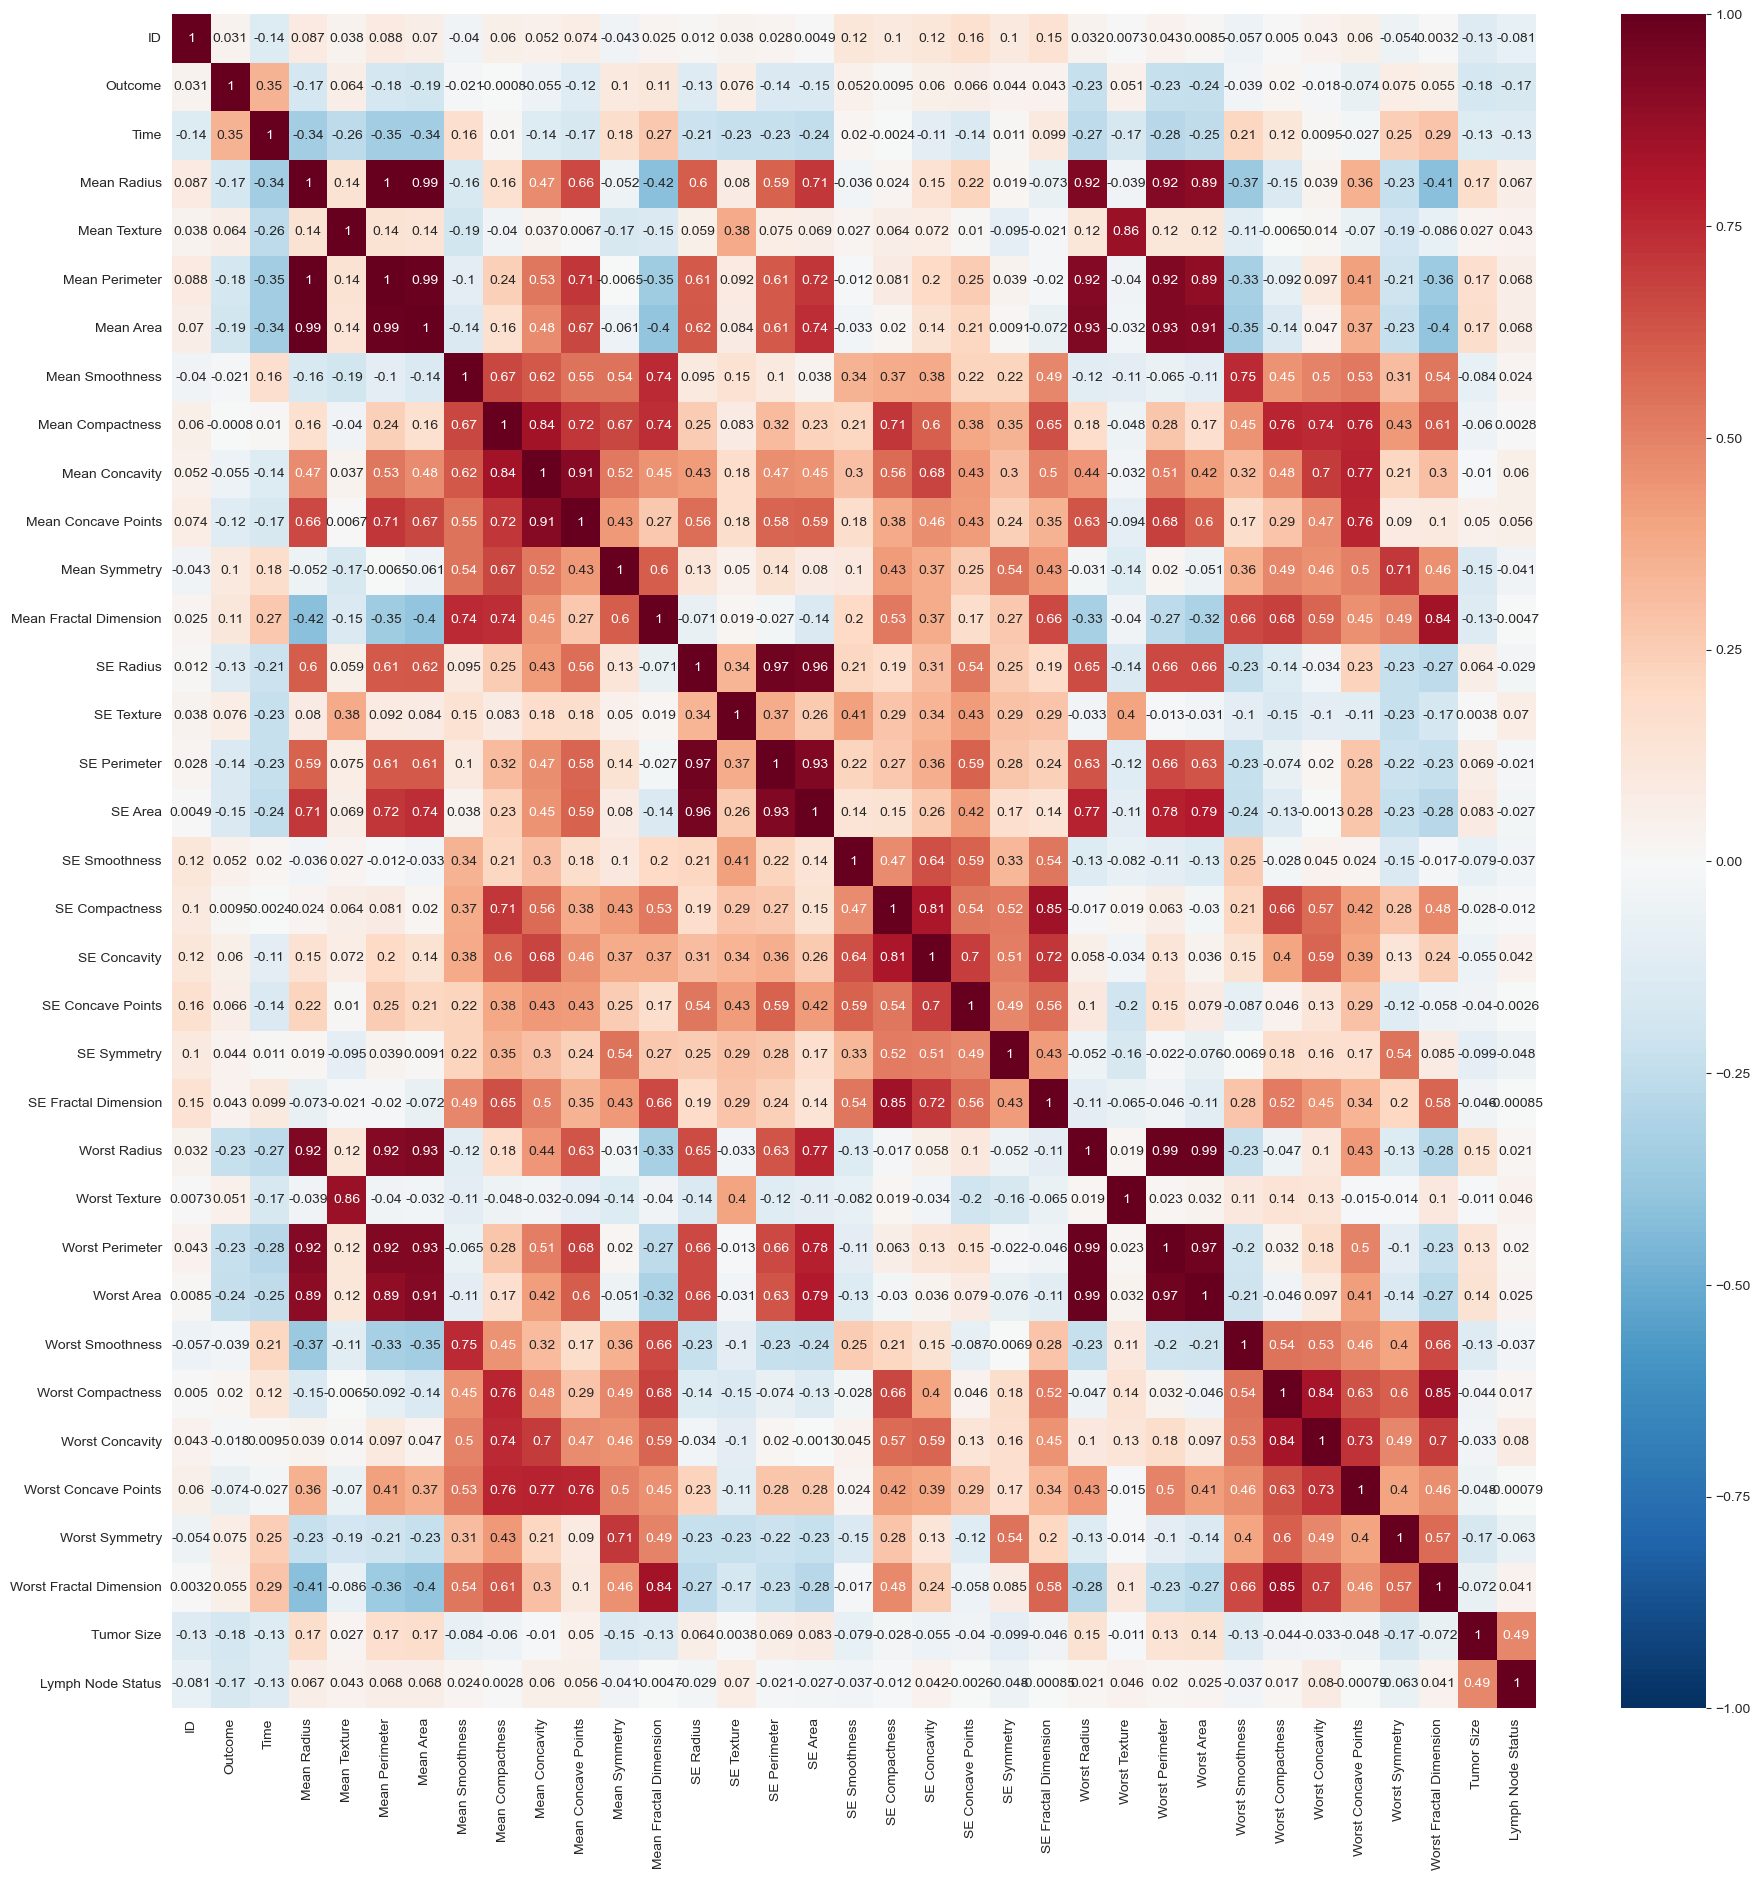

In [9]:
#Using heatmap to plot the correlation between all the columns in the dataset
plt.figure(figsize=(22,22))
sns.heatmap(df.corr(), cmap='RdBu_r', annot=True, vmax=1, vmin=-1)
plt.show()

#### e. What is the correlation between Mean Perimeter and SE Perimeter

In [10]:
#Using the correlation function to determine correlation between two variables
correlation = df['Mean Perimeter'].corr(df['SE Perimeter'])
correlation

0.6099643781634987

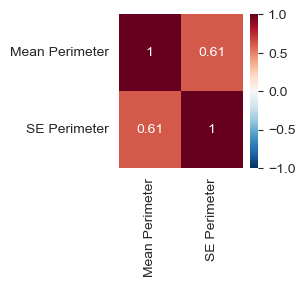

In [11]:
#Printing the correlation Matrix between the two variables
correlation_matrix = np.corrcoef(df['Mean Perimeter'], df['SE Perimeter'])
correlation_matrix

#plotting a heatmap for pictorial representation
plt.figure(figsize=(2,2))
sns.heatmap(correlation_matrix, cmap='RdBu_r', annot=True, vmax=1, vmin=-1, xticklabels=["Mean Perimeter", "SE Perimeter"], yticklabels=["Mean Perimeter", "SE Perimeter"])
plt.show()

### 2. Logistic Regression with One Variable

a. Can you map the likelihood of breast cancer recurrence (Outcome) based on "Mean Area”
feature from the dataset?

In [12]:
#Normalizing the Mean Area data and assigning it to a variable
x = (x['Mean Area'] - x['Mean Area'].mean()) / (x['Mean Area'].std())

In [13]:
#Printing the variables
x,y

(0      0.121991
 1      0.087915
 2      1.144285
 3     -1.658220
 4      0.928467
          ...   
 193    1.780379
 194   -0.652113
 195   -0.155448
 196    1.334545
 197   -0.240355
 Name: Mean Area, Length: 198, dtype: float64,
 0      1
 1      1
 2      1
 3      1
 4      0
       ..
 193    1
 194    1
 195    1
 196    0
 197    1
 Name: Outcome, Length: 198, dtype: int64)

In [14]:
#Defining a function to split data into training & testing
def df_split(df,test_split):
    
    array_lenght = len(df)
    test_num = int(array_lenght * test_split)
    
    #Spliting into training & testing
    x_train = x[:test_num]
    y_train = y[:test_num]
    x_test = x[test_num:]
    y_test = y[test_num:]
    
    #returning the values
    return x_train, y_train, x_test, y_test

In [15]:
#Calling the data split function
x_train, y_train, x_test, y_test = df_split(df,0.8)

#printing the values
x_train, y_train, x_test, y_test 

(0      0.121991
 1      0.087915
 2      1.144285
 3     -1.658220
 4      0.928467
          ...   
 153    0.029701
 154   -0.437999
 155    0.559306
 156   -0.319299
 157    0.104953
 Name: Mean Area, Length: 158, dtype: float64,
 0      1
 1      1
 2      1
 3      1
 4      0
       ..
 153    1
 154    1
 155    0
 156    1
 157    0
 Name: Outcome, Length: 158, dtype: int64,
 158    0.278175
 159    0.993781
 160   -1.062450
 161    2.768597
 162   -0.677954
 163   -0.761441
 164    0.232740
 165    0.692772
 166    2.473267
 167    0.229900
 168   -0.718846
 169    1.070453
 170    1.445294
 171    0.826238
 172   -0.317879
 173   -1.062734
 174    0.000452
 175    1.468011
 176   -0.009771
 177    0.040776
 178    2.115464
 179   -0.596454
 180   -0.570897
 181    0.445718
 182   -0.564934
 183    1.516286
 184    0.070876
 185   -1.138270
 186    2.087067
 187    1.584439
 188   -1.360619
 189    0.752406
 190    0.760925
 191    0.465596
 192   -0.887524
 193    1.780379
 

In [16]:
#Sigmoid Function
def sigmoid(z):
    #Formula for sigmoid
    sig = 1 / (1 + np.exp(-z))
    return sig

In [17]:
#Gradient Descent Function
def gradient_descent(x, y, w, c, l):
    m = len(x)
    z = np.dot(x, w) + c
    #Calculating the sigmoid of the values for predictions
    pred = (sigmoid(z))

    #Calculating gradients
    gradient_w = (1/m) * (np.dot((pred - y), x))
    gradient_c = (1/m) * (np.sum(pred - y))
        
    #Calculating the final weights
    w = w - l * gradient_w
    c = c - l * gradient_c
    
    #Returning the weights
    return w, c

In [18]:
#Cost Function
def cost_function (x, y, w, c):
    m = len(x)
    pred = []

    # Calculate the predictions
    z = (np.dot(x,w) + c)
    pred = (sigmoid(z))
    
    #Calculating the cost for Logistic Regression model
    cost = -(1/(m)) * (np.sum(y * np.log(pred) + (1-y) * np.log(1-pred)))

    return cost

In [19]:
#Calculating the Gradient Descent, Cost and Prediction
#Setting iterations to 200
num_iterations = 200

#Initializing Weights
n = x_train.shape
w = 0
c = 0

#Array to store the cost values for graph plotting purposes
cost_plot = []

#Loop for Calculating weights, Cost & Predictions for 200 iterations
for i in range (num_iterations):
    #Calculating weights
    w,c = gradient_descent(x_train, y_train, w, c, l = 0.7)
    
    #Calculating Cost
    cost = (cost_function (x_test, y_test, w, c))
    cost_plot.append(cost)

    #Calculating predictions
    pred = (sigmoid(np.dot(x_test,w) + c))
    
#Printing the values   
print ("w Value = ", w, "\n")
print ("c Value = ", c, "\n")
print("The Cost is = ", cost,"\n")
print ("The predicted Values are = \n", pred)

w Value =  -0.5114487368080947 

c Value =  1.0185098298872004 

The Cost is =  0.45518989491955164 

The predicted Values are = 
 [0.70604195 0.62486319 0.82662561 0.40191666 0.79661139 0.80344208
 0.71084169 0.66020155 0.43870004 0.71114013 0.7999789  0.61562707
 0.56937855 0.64472493 0.76514351 0.82664642 0.73463719 0.56652749
 0.73565521 0.73059731 0.48414489 0.78977432 0.78759587 0.68794902
 0.78708519 0.56045455 0.72755645 0.83211293 0.48777292 0.5518505
 0.84740569 0.65332634 0.65233884 0.68576235 0.81342689 0.52695813
 0.79446163 0.74988772 0.58320841 0.75794378]


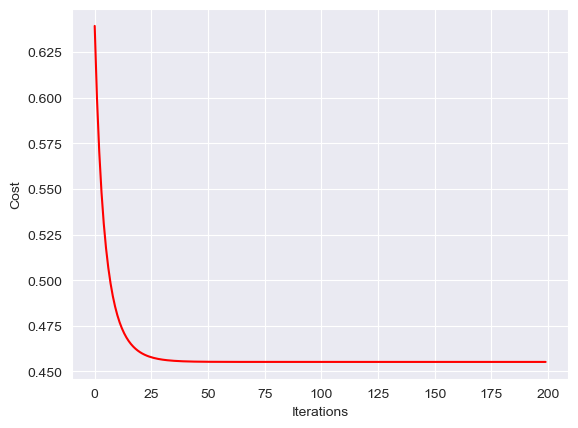

In [20]:
#Plotting a graph for cost over 200 iterations
plt.plot (cost_plot, color = "red")
plt.xlabel ("Iterations")
plt.ylabel ("Cost")
plt.show()

In [21]:
#Converting predictions into 1s & 0s
predictions = []

for i in pred:
    #Setting prediction to 1 if value is greater than or equals 0.5
    if i >=0.5:
        predictions.append(1)
    
    #Setting prediction to 0 if value is less than 0.5
    else:
        predictions.append(0)

In [22]:
#Final prediction values of the model    
print((predictions))
print((list(y_test)))

[1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
[1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1]


#### b. Evaluate performance using a metric discussed in class (such as confusion matrix). You may also use graphs to explain your observations.

In [23]:
#Function to calculate the Confusion Matrix
def calculate_cm(predictions, y_test):
    TP = 0 #True Positive
    TN = 0 #True Negative
    FP = 0 #False Positive
    FN = 0 #False Negative

    #Depending on the prediction values, increment the count of the variables TP, TN, FP, FN.
    for pred, y_test in zip(predictions, list(y_test)):
        if pred == y_test:
            if pred == 1:
                TP += 1
            else:
                TN += 1
        else:
            if pred == 1:
                FP += 1
            else:
                FN += 1

    #Return the final confusion matrix
    confusion_matrix = [[TN, FP],[FN, TP]]
    return TP, TN, FP, FN, confusion_matrix

In [24]:
#Calling the confusion matrix function and storing the values returned in these variables
TP, TN, FP, FN, confusion_matrix = calculate_cm(predictions, y_test)

In [25]:
#Defining a function to calculate the Performance Metrics
def performance_eval (TP, TN, FP, FN):
    #Initializing the values
    accuracy = None
    precision = None
    recall = None
    f1_score = None
    
    #Using a try-catch in case of divide by zero 
    try:
        accuracy = (TP + TN)/(TP + TN + FP + FN)
        precision = TP / (TP + FP)
        recall = TP / (TP + FN)
        f1_score = 2 * ((precision * recall) / (precision + recall))
    
    except:
        print("Error Calculating the metrics")
    
    #Returning the values
    return precision, recall, f1_score, accuracy

In [26]:
#Calling the Performance evaluation function and storing the values returned in these variables
precision, recall, f1_score, accuracy = performance_eval(TP, TN, FP, FN)

In [27]:
#Defining a function to print all the results
def print_(TP, TN, FP, FN, confusion_matrix, precision, recall, f1_score, accuracy):
    print("True Positive = ", TP, "\nTrue Negative = ", TN, "\nFalse Positive = ", FP, "\nFalse Negative = ", FN, "\n")
    print("\nConfusion Matrix [[TN, FP],[FN, TP]] = ", confusion_matrix)
    print("\n\nPrecision = ", precision, "\nRecall = ", recall, "\nF1 Score = ", f1_score, "\nAccuracy = ", accuracy)

In [28]:
#Priniting the results for performance evaluation purposes
print_(TP, TN, FP, FN, confusion_matrix, precision, recall, f1_score, accuracy)

True Positive =  32 
True Negative =  1 
False Positive =  4 
False Negative =  3 


Confusion Matrix [[TN, FP],[FN, TP]] =  [[1, 4], [3, 32]]


Precision =  0.8888888888888888 
Recall =  0.9142857142857143 
F1 Score =  0.9014084507042254 
Accuracy =  0.825


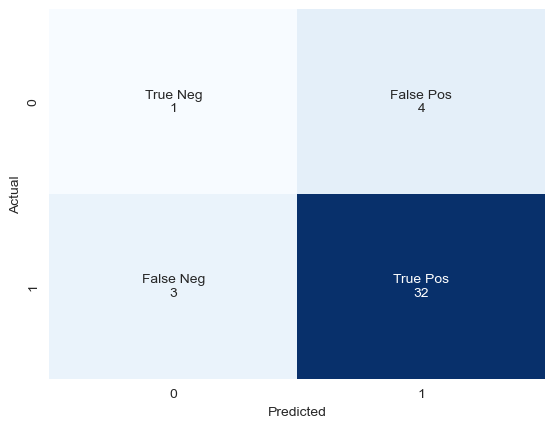

In [29]:
#Plotting the Confusion Matrix
group_names = ['True Neg', 'False Pos', 'False Neg', 'True Pos']

# Format the values in the confusion matrix as strings
group_counts = [f"{value}" for row in confusion_matrix for value in row]

# Create labels that combine group_names and group_counts
labels = [f'{name}\n{count}' for name, count in zip(group_names, group_counts)]

labels = np.array(labels).reshape(2, 2)

fig, ax = plt.subplots()
heatmap = sns.heatmap(confusion_matrix, annot=labels, fmt='', cmap='Blues', cbar=False)

# Add labels for the x and y axes
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

### 3. Logistic Regression with Multiple Variables

#### a. Design a Logistic Regression model to predict breast cancer recurrence (Outcome) using the following 12 variables from the dataset as input features.

#### Features: Mean radius, Mean texture, Mean perimeter, Mean area, Mean smoothness, Mean compactness, Mean concavity, Mean concave points, Mean fractal dimension, SE perimeter, SE texture, SE area

In [30]:
#Selecting the features from the dataset and storing them into variable x
features = ['Mean Radius', 'Mean Texture', 'Mean Perimeter', 'Mean Area', 'Mean Smoothness', 'Mean Compactness', 'Mean Concavity', 'Mean Concave Points', 'Mean Fractal Dimension', 'SE Perimeter', 'SE Texture', 'SE Area']
x = df[features]
x

,Mean Radius,Mean Texture,Mean Perimeter,Mean Area,Mean Smoothness,Mean Compactness,Mean Concavity,Mean Concave Points,Mean Fractal Dimension,SE Perimeter,SE Texture,SE Area
0,18.02,27.60,117.50,1013.0,0.09489,0.10360,0.10860,0.07055,0.06333,3.972,1.8900,71.55
1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.07871,8.589,0.9053,153.40
2,21.37,17.44,137.50,1373.0,0.08836,0.11890,0.12550,0.08180,0.06010,3.928,0.6105,82.15
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.09744,3.445,1.1560,27.23
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.05883,5.438,0.7813,94.44
...,...,...,...,...,...,...,...,...,...,...,...,...
193,22.52,21.92,146.90,1597.0,0.07592,0.09162,0.06862,0.06367,0.05262,9.938,2.3120,192.40
194,15.44,31.18,101.00,740.4,0.09399,0.10620,0.13750,0.06500,0.06105,1.971,1.8390,32.61
195,17.17,29.19,110.00,915.3,0.08952,0.06655,0.06583,0.05068,0.05392,3.827,1.4250,63.02
196,21.42,22.84,145.00,1440.0,0.10700,0.19390,0.23800,0.13180,0.06472,8.308,0.8469,142.50


In [31]:
#Feature Scaling
x = (x - x.mean()) / (x.std())
x

,Mean Radius,Mean Texture,Mean Perimeter,Mean Area,Mean Smoothness,Mean Compactness,Mean Concavity,Mean Concave Points,Mean Fractal Dimension,SE Perimeter,SE Texture,SE Area
0,0.192201,1.238630,0.123621,0.121991,-0.622197,-0.782558,-0.675092,-0.478962,0.086262,-0.129160,1.188204,0.027536
1,0.182712,-2.767615,0.371477,0.087915,1.255234,2.704583,2.038439,1.780708,2.210709,1.975093,-0.682189,1.733375
2,1.251766,-1.125101,1.058926,1.144285,-1.143661,-0.475930,-0.435621,-0.146874,-0.359900,-0.149214,-1.242148,0.248451
3,-1.895300,-0.441108,-1.743248,-1.658220,3.179781,2.830842,1.206667,0.543867,4.797894,-0.369347,-0.205996,-0.896138
4,0.910175,-1.846318,0.946689,0.928467,-0.190172,-0.197360,0.591695,0.517300,-0.535326,0.538987,-0.917722,0.504588
...,...,...,...,...,...,...,...,...,...,...,...,...
193,1.615497,-0.082826,1.498519,1.780379,-2.137078,-1.022650,-1.241604,-0.682051,-1.393116,2.589916,1.989774,2.546176
194,-0.623822,2.071519,-0.648006,-0.652113,-0.694068,-0.730451,-0.265583,-0.642791,-0.228676,-1.041140,1.091332,-0.784014
195,-0.076644,1.608544,-0.227118,-0.155448,-1.051027,-1.525079,-1.281138,-1.065502,-1.213546,-0.195246,0.304957,-0.150238
196,1.267580,0.131213,1.409665,1.334545,0.344868,1.027148,1.158489,1.329069,0.278263,1.847024,-0.793117,1.506208


In [32]:
#Splitting data into training and testing
x_train, y_train, x_test, y_test = df_split(df,0.8)

In [33]:
#Displaying the values
x_train, y_train, x_test, y_test 

(     Mean Radius  Mean Texture  Mean Perimeter  Mean Area  Mean Smoothness  \
 0       0.192201      1.238630        0.123621   0.121991        -0.622197   
 1       0.182712     -2.767615        0.371477   0.087915         1.255234   
 2       1.251766     -1.125101        1.058926   1.144285        -1.143661   
 3      -1.895300     -0.441108       -1.743248  -1.658220         3.179781   
 4       0.910175     -1.846318        0.946689   0.928467        -0.190172   
 ..           ...           ...             ...        ...              ...   
 153     0.059360      0.245211        0.193769   0.029701        -0.781910   
 154    -0.367629     -0.643514       -0.236472  -0.437999        -0.006501   
 155     0.641330     -0.804043        0.619332   0.559306         0.496596   
 156    -0.228462     -0.482985       -0.362738  -0.319299        -2.212942   
 157     0.189038     -0.399231        0.165710   0.104953        -0.206143   
 
      Mean Compactness  Mean Concavity  Mean Conca

In [34]:
#Calculating the Gradient Descent, Cost and Predictions

#Initialize iterations
num_iterations = 200

#Initialize weights
n = x_train.shape[1]
w = np.zeros(n)
c = 0
cost_plot1 = []

#Loop for calcuating the weights, Cost and Predictions
for i in range (num_iterations):
    w,c = gradient_descent(x_train, y_train, w, c, l = 0.7)
    cost = (cost_function (x_test, y_test, w, c))
    cost_plot1.append(cost)
    pred1 = (sigmoid(np.dot(x_test,w) + c))

#Printing the values
print ("w Values = ", w, "\n")
print ("c Value = ", c, "\n")
print("The Cost is = ", cost,"\n")
print ("The predicted Values are = \n", pred1)

w Values =  [ 0.22482908 -0.07406684 -0.17476886 -0.57819363 -0.77798834 -0.02958095
  0.3198775   0.12639061  0.60330531 -0.93603959  0.27796962  0.58242612] 

c Value =  1.0910284510707866 

The Cost is =  0.44830971732780567 

The predicted Values are = 
 [0.80480083 0.64345948 0.84408208 0.35482694 0.85379331 0.84502936
 0.67700606 0.62955214 0.53182574 0.74466602 0.92682307 0.48827036
 0.37499306 0.69978539 0.79874681 0.63261847 0.80304816 0.57403106
 0.76288885 0.77190224 0.75117705 0.83628183 0.77702959 0.4977876
 0.81102127 0.62851732 0.7075077  0.86839044 0.26590784 0.68091362
 0.91098413 0.58288167 0.74412603 0.76507714 0.87544917 0.53740499
 0.9142246  0.70065903 0.42164102 0.78840651]


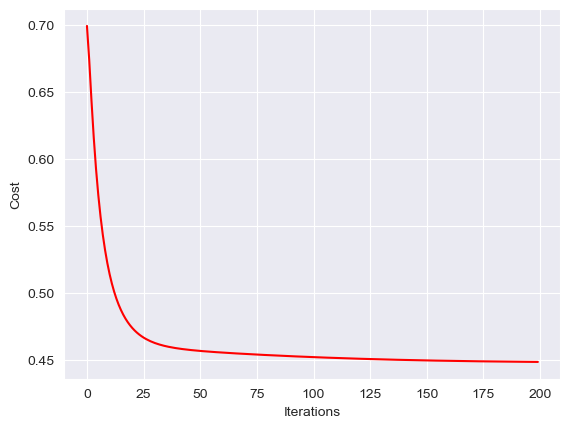

In [35]:
#Plotting a graph for cost over multiple iterations
plt.plot (cost_plot1, color = "red")
plt.xlabel ("Iterations")
plt.ylabel ("Cost")
plt.show()

In [36]:
#Converting predictions into 1s & 0s
predictions1 = []

for i in pred1:
    #Setting prediction to 1 if value is greater than or equals 0.5
    if i >=0.5:
        predictions1.append(1)
    
    #Setting prediction to 0 if value is less than 0.5
    else:
        predictions1.append(0)

In [37]:
#Printing the Predicted & Actual values
print(predictions1)
print(list(y_test))

[1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1]
[1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1]


In [38]:
#Calculating the Confusion Matrix, Precision, Accuracy, Recall & F1 Score
TP_1, TN_1, FP_1, FN_1, confusion_matrix_1 = calculate_cm(predictions1, y_test)
precision_1, recall_1, f1_score_1, accuracy_1 = performance_eval(TP_1, TN_1, FP_1, FN_1)

In [39]:
#Printing the values
print_(TP_1, TN_1, FP_1, FN_1, confusion_matrix_1, precision_1, recall_1, f1_score_1, accuracy_1)

True Positive =  31 
True Negative =  2 
False Positive =  3 
False Negative =  4 


Confusion Matrix [[TN, FP],[FN, TP]] =  [[2, 3], [4, 31]]


Precision =  0.9117647058823529 
Recall =  0.8857142857142857 
F1 Score =  0.8985507246376812 
Accuracy =  0.825


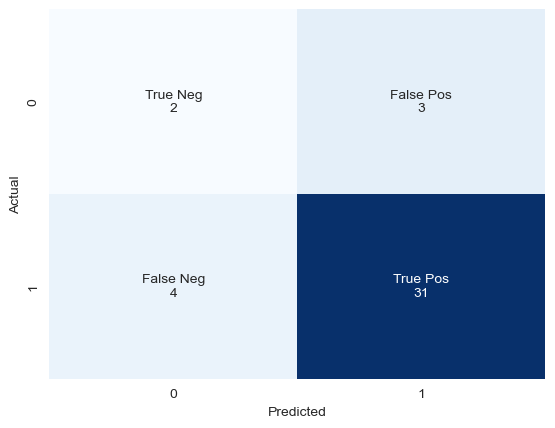

In [40]:
#Plotting the Confusion Matrix
group_names = ['True Neg', 'False Pos', 'False Neg', 'True Pos']

# Format the values in the confusion matrix as strings
group_counts = [f"{value}" for row in confusion_matrix_1 for value in row]

# Create labels that combine group_names and group_counts
labels = [f'{name}\n{count}' for name, count in zip(group_names, group_counts)]

labels = np.array(labels).reshape(2, 2)

fig, ax = plt.subplots()
heatmap = sns.heatmap(confusion_matrix, annot=labels, fmt='', cmap='Blues', cbar=False)

# Add labels for the x and y axes
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

#### b. Design a Logistic Regression model to predict breast cancer recurrence (Outcome) using forward selection to select the most significant variables in the dataset as input features. Which subset of features gave you the best performance? What are your thoughts on these features getting selected? (Use 12 features from 3a as Input features)

In [41]:
#Defining a function for calculating the weights
def gradiant_descent_flr(x, y, learning_rate=0.007, num_iterations=200):
    #Initializing the weights
    no_of_values = x.shape[0]
    w = np.zeros(x.shape[1])
    c = 0
    
    #Loop for calculating the weights
    for _ in range(num_iterations):
        #Predictions
        z = np.dot(x, w) + c
        h = sigmoid(z)
        
        #Calculating gradient
        gradient_w = np.dot((h - y), x) / no_of_values
        gradient_c = np.sum((h - y)) / no_of_values
        
        #Calculating final weight
        w -= learning_rate * gradient_w
        c -= learning_rate * gradient_c

    #Return the weights
    return w, c

In [42]:
#Defining a function for Forward logistic stepwise regression
def forward_split_lr(x, y, features_selected, features):
    #Initializing Accuracy & Result arrays
    acc = []
    iter_results = []
    best_results = []
    
    #Outer loop to iterate the selected feature
    while len(features_selected) < len(features):
        #Initialize the arrays to store the best features, accuracies & f1 scores
        best_acc = 0
        best_f1 = 0
        best_features = None
        
        #Inner loop to calculate forward stepwise
        for feature_name in features:
            if feature_name not in features_selected:
                feature_subset = features_selected + [feature_name]
                
                #Storing training and testing into 2 different subsets
                subset_1 = x_train[feature_subset]
                subset_2 = x_test[feature_subset]
                
                #calculating weights
                w, c = gradiant_descent_flr(subset_1, y_train)
                
                #Calculate predictions
                z = np.dot(subset_2, w) + c
                predictions = (sigmoid(z) >= 0.5).astype(int)
                
                #Calculating confusion matrix & other evaluation metrics
                tp,tn,fp,fn,cm = calculate_cm(y_test, predictions)
                precision = (tp) / (fp + tp)
                recall = (tp) / (fn + tp)
                f1 = (2 * precision * recall) / (precision + recall)
                accuracy = (tp + tn) / (tp + tn + fp + fn)
                
                #Storing the results in a dictionary
                model_data = {
                    "precision": precision,
                    "recall": recall,
                    "accuracy": accuracy,
                    "f1": f1,
                    "confusion matrix": cm,
                    "features": ", ".join(feature_subset),
                }
                
                iter_results.append(model_data)
                
                #Chosing the best feature based on the accuracy & f1 score
                if accuracy > best_acc and f1 > best_f1:
                    best_acc = accuracy
                    best_f1 = f1
                    best_features = feature_name
        
        #Storing the best feature
        if best_features is not None:
            features_selected.append(best_features)
            acc.append(best_acc)
        else:
            break
            
        #Storing the best results
        for i in iter_results:
            if i['features'] == ", ".join(features_selected):
                best_results.append(i)

    #Printing the results
    for i in best_results:
        print(i, end="\n\n")

    for i in iter_results:
        print(i, end="\n\n")

In [43]:
# Initialize your data
selected_feature_names = []
feature_names = x.columns.tolist()
#outcome = y

# Call the evaluate_model function to start feature selection
forward_split_lr(x, y, selected_feature_names, feature_names)

{'precision': 1.0, 'recall': 0.875, 'accuracy': 0.875, 'f1': 0.9333333333333333, 'confusion matrix': [[0, 0], [5, 35]], 'features': 'Mean Texture'}

{'precision': 1.0, 'recall': 0.875, 'accuracy': 0.875, 'f1': 0.9333333333333333, 'confusion matrix': [[0, 0], [5, 35]], 'features': 'Mean Texture, Mean Smoothness'}

{'precision': 1.0, 'recall': 0.875, 'accuracy': 0.875, 'f1': 0.9333333333333333, 'confusion matrix': [[0, 0], [5, 35]], 'features': 'Mean Texture, Mean Smoothness, Mean Compactness'}

{'precision': 1.0, 'recall': 0.875, 'accuracy': 0.875, 'f1': 0.9333333333333333, 'confusion matrix': [[0, 0], [5, 35]], 'features': 'Mean Texture, Mean Smoothness, Mean Compactness, Mean Concavity'}

{'precision': 1.0, 'recall': 0.875, 'accuracy': 0.875, 'f1': 0.9333333333333333, 'confusion matrix': [[0, 0], [5, 35]], 'features': 'Mean Texture, Mean Smoothness, Mean Compactness, Mean Concavity, Mean Fractal Dimension'}

{'precision': 0.9428571428571428, 'recall': 0.868421052631579, 'accuracy': 0.

#### 3c. Compare the performance of the full model built using all the features in (3a) with the resultant accuracies of the full model using the selected features (3b). Which set of features performed better?

In [44]:
#Printing the results for the model from 3a & the best model from 3b
print("Full model built using all the features in 3a:\n")
print_(TP_1, TN_1, FP_1, FN_1, confusion_matrix_1, precision_1, recall_1, f1_score_1, accuracy_1)
print("-------------------------------------------------------------------------")
print("\nFull model built using forward selection in 3b:\n")
print("\nConfusion matrix': [[0, 0], [5, 35]]\n\nPrecision = 1.0\nRecall = 0.875\nF1_score = 0.9333333333333333\nAccuracy = 0.875\nFeatures: Mean Texture")

Full model built using all the features in 3a:

True Positive =  31 
True Negative =  2 
False Positive =  3 
False Negative =  4 


Confusion Matrix [[TN, FP],[FN, TP]] =  [[2, 3], [4, 31]]


Precision =  0.9117647058823529 
Recall =  0.8857142857142857 
F1 Score =  0.8985507246376812 
Accuracy =  0.825
-------------------------------------------------------------------------

Full model built using forward selection in 3b:


Confusion matrix': [[0, 0], [5, 35]]

Precision = 1.0
Recall = 0.875
F1_score = 0.9333333333333333
Accuracy = 0.875
Features: Mean Texture


#### On comparing the models from 3a & 3b, it is clear that the model obtained from forward selection performs better.

### 4. Experimenting with regularization and Cost function.

#### a. Regularization and Feature Scaling:

#### I. For the best performing model in Q.3 (Model from 3c), does regularization improve the performance?

We will be picking the best model from 3c.
i.e., the features are Mean Area, Mean Texture, Mean Fractal Dimension.

In [45]:
#Since we have only 1 variable as the best model from 3c, we initialize a variable with only that feature
features_1 = ['Mean Texture']
x = df[features_1]
x

,Mean Texture
0,27.60
1,10.38
2,17.44
3,20.38
4,14.34
...,...
193,21.92
194,31.18
195,29.19
196,22.84


In [46]:
#Feature Scaling
x = (x - x.mean()) / (x.std())
x.head()

,Mean Texture
0,1.238630
1,-2.767615
2,-1.125101
3,-0.441108
4,-1.846318


In [47]:
#Splitting data into training and testing
x_train, y_train, x_test, y_test = df_split(df,0.8)

#Printing the values
x_train, y_train, x_test, y_test 

(     Mean Texture
 0        1.238630
 1       -2.767615
 2       -1.125101
 3       -0.441108
 4       -1.846318
 ..            ...
 153      0.245211
 154     -0.643514
 155     -0.804043
 156     -0.482985
 157     -0.399231
 
 [158 rows x 1 columns],
 0      1
 1      1
 2      1
 3      1
 4      0
       ..
 153    1
 154    1
 155    0
 156    1
 157    0
 Name: Outcome, Length: 158, dtype: int64,
      Mean Texture
 158     -1.106489
 159     -0.241028
 160      0.515086
 161     -0.822655
 162      0.389455
 163     -0.745880
 164     -0.394578
 165     -0.469026
 166     -0.157274
 167      2.120376
 168      1.941235
 169      0.654677
 170      0.026520
 171      1.389853
 172      1.350302
 173      0.361537
 174      0.905939
 175      1.945888
 176      0.698880
 177      2.027316
 178      0.745410
 179      1.050183
 180     -1.204202
 181     -0.324783
 182      0.519739
 183      1.196753
 184      0.391781
 185      0.563943
 186      2.697350
 187      1.785359
 18

In [48]:
#Function for Regularized Gradient Descent
def reg_gradient_descent(x, y, w, c, l):
    m = len(x)
    lamda = 1000 #Shrinkage Parameter
    
    #Calculating Predictions
    z = np.dot(x, w) + c
    pred = (sigmoid(z))
    
    #Calculating Gradient
    gradient_w = ((1/m) * (np.dot((pred - y), x))) + ((lamda / m) * w)
    gradient_c = (1/m) * (np.sum(pred - y))
        
    #Calculating final weights
    w = w - l * gradient_w
    c = c - l * gradient_c
    
    return w, c

In [49]:
#Regularized Cost Function
def reg_cost_function (x, y, w, c):
    m = len(x)
    pred = []
    lamda = 1000

    epsilon = 1e-15  # A small constant to prevent log(0)

    #Calculate the predictions
    z = (np.dot(x,w) + c)
    pred = (sigmoid(z))
    
    #Calculating Cost
    reg_term = (lamda / (2 * m)) * np.sum(w**2)
    reg_cost = (-(1/(m)) * (np.sum(y * np.log(pred + epsilon) + (1-y) * np.log(1-pred + epsilon)))) + reg_term

    return reg_cost

In [50]:
import warnings #For removing divide by zero warning

#Initializing the weights
num_iterations = 1000
n = x_train.shape[1]
w = np.zeros(n)
c = 0
cost_plot2 = []

w1 = np.zeros(n)
c1 = 0
cost_plot_2 = []

warnings.filterwarnings('ignore', category=RuntimeWarning)

#Loop to calculate cost & gradient descent & predictions over multiple iterations
for i in range (num_iterations):
    
    #Cost Function without Regularization:
    w,c = gradient_descent(x_train, y_train, w, c, l = 0.7)
    cost_1 = (cost_function(x_test, y_test, w, c))
    cost_plot2.append(cost_1) 
    pred_1 = (sigmoid(np.dot(x_test,w) + c))
    
    #Cost Function with Regularization:
    w1,c1 = reg_gradient_descent(x_train, y_train, w1, c1, l = 0.02)
    reg_cost = reg_cost_function(x_test, y_test, w1, c1)
    cost_plot_2.append(reg_cost)
    pred_2 = (sigmoid(np.dot(x_test,w1) + c1))

#printing the normal & regularized values 
print("Values without Regularization:\n")
print ("w Values = ", w, "\n")
print ("c Value = ", c, "\n")
print("The Cost is = ", cost_1,"\n")
print ("The predicted Values are = \n", pred_1)

print("----------------------------------------------------------------------------------------------------------")

print("Values with Regularization:\n")
print ("w1 Values = ", w1, "\n")
print ("c1 Value = ", c1, "\n")
print("The Regularized Cost is = ", reg_cost,"\n")
print ("The predicted Values are = \n", pred_2)

Values without Regularization:

w Values =  [-0.00465592] 

c Value =  1.0151135371042423 

The Cost is =  0.4367553149305674 

The predicted Values are = 
 [0.73502427 0.73423872 0.73355121 0.7347668  0.73366552 0.73469714
 0.7343782  0.73444581 0.73416262 0.73208782 0.73225138 0.73342416
 0.73399558 0.7327544  0.73279046 0.73369092 0.73319537 0.73224713
 0.73338392 0.73217279 0.73334156 0.73306398 0.73511286 0.73431481
 0.73354697 0.73293042 0.7336634  0.73350675 0.7315606  0.73239364
 0.73217492 0.73440355 0.73293254 0.7329813  0.73338816 0.73409497
 0.73213243 0.73255496 0.73390039 0.73277985]
----------------------------------------------------------------------------------------------------------
Values with Regularization:

w1 Values =  [-0.00021082] 

c1 Value =  0.9990450831758252 

The Regularized Cost is =  0.4384293929862341 

The predicted Values are = 
 [0.73091667 0.73088078 0.73084943 0.7309049  0.73085464 0.73090172
 0.73088715 0.73089024 0.73087731 0.73078285 0.730790

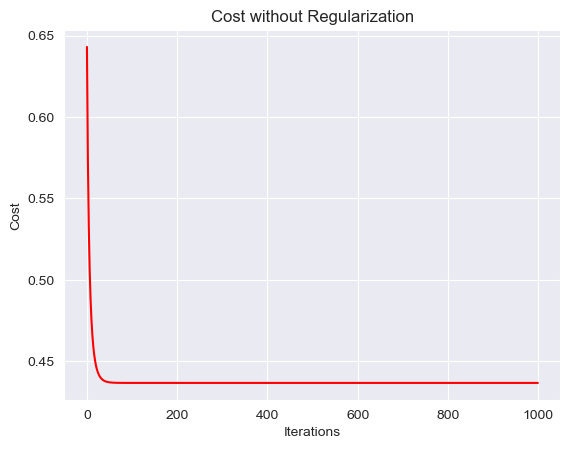

In [51]:
#Plotting the graph for cost function without regularization
plt.plot(cost_plot2, color = "red")
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Cost without Regularization")
plt.show()

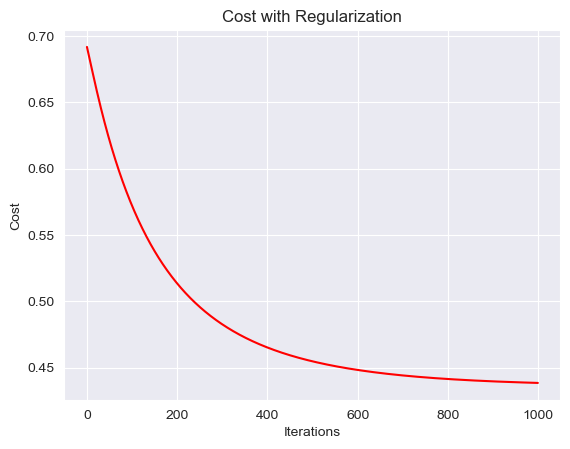

In [52]:
#Plotting the graph for cost function with regularization
plt.plot(cost_plot_2, color = "red")
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Cost with Regularization")
plt.show()

In [53]:
#Converting predictions into 1s & 0s
predictions2 = []
for i in pred_2:
    #Setting prediction to 1 if value is greater than or equals 0.5
    if i >=0.5:
        predictions2.append(1)
        
    #Setting prediction to 0 if value is less than 0.5
    else:
        predictions2.append(0)

In [54]:
#Printing the actual & predicted values
print(predictions2)
print(list(y_test))


[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
[1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1]


In [55]:
#Calculating the confusion matrix & performance evaluation parameters
TP_2, TN_2, FP_2, FN_2, confusion_matrix_2 = calculate_cm(predictions2, y_test)
precision_2, recall_2, f1_score_2, accuracy_2 = performance_eval(TP_2, TN_2, FP_2, FN_2)

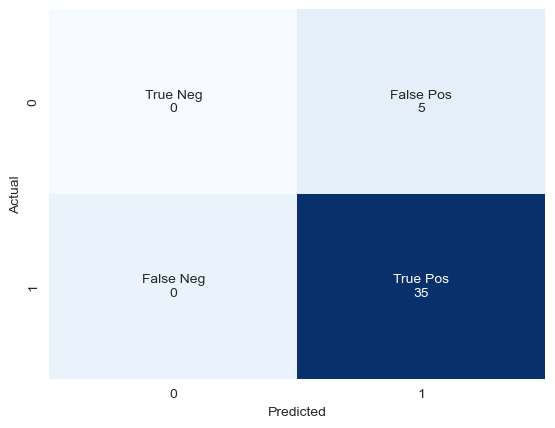

In [56]:
#Plotting the Confusion Matrix
group_names = ['True Neg', 'False Pos', 'False Neg', 'True Pos']

# Format the values in the confusion matrix as strings
group_counts = [f"{value}" for row in confusion_matrix_2 for value in row]

# Create labels that combine group_names and group_counts
labels = [f'{name}\n{count}' for name, count in zip(group_names, group_counts)]

labels = np.array(labels).reshape(2, 2)

fig, ax = plt.subplots()
heatmap = sns.heatmap(confusion_matrix, annot=labels, fmt='', cmap='Blues', cbar=False)

# Add labels for the x and y axes
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [57]:
#Printing the performanc evaluation parameters
print_(TP_2, TN_2, FP_2, FN_2, confusion_matrix_2, precision_2, recall_2, f1_score_2, accuracy_2)

True Positive =  35 
True Negative =  0 
False Positive =  5 
False Negative =  0 


Confusion Matrix [[TN, FP],[FN, TP]] =  [[0, 5], [0, 35]]


Precision =  0.875 
Recall =  1.0 
F1 Score =  0.9333333333333333 
Accuracy =  0.875


In [58]:
#Printing the performance evaluation paramerters form 3b's best model
print("\nFull model built using forward selection in 3b:")
print("\nConfusion matrix: [[0, 0], [5, 35]]\n\nPrecision = 1.0\nRecall = 0.875\nF1_score = 0.9333333333333333\nAccuracy = 0.875\nFeatures: Mean Texture")


Full model built using forward selection in 3b:

Confusion matrix: [[0, 0], [5, 35]]

Precision = 1.0
Recall = 0.875
F1_score = 0.9333333333333333
Accuracy = 0.875
Features: Mean Texture


#### Based on the above results, the Accuracy, F1 Score and Cost of the model is better without regularization. Hence the previous model performed better.

#### II. Does Feature Scaling improve the performance for the model in Q 3c?

#### We already used feature scaling in our previous code. Now we will build the model without feature scaling

In [59]:
#Initializing the input variable
x = df[features_1]
x

,Mean Texture
0,27.60
1,10.38
2,17.44
3,20.38
4,14.34
...,...
193,21.92
194,31.18
195,29.19
196,22.84


In [60]:
#Splitting it into training & testing
x_train, y_train, x_test, y_test = df_split(df,0.8)

#Printing the values
x_train, y_train, x_test, y_test 

(     Mean Texture
 0           27.60
 1           10.38
 2           17.44
 3           20.38
 4           14.34
 ..            ...
 153         23.33
 154         19.51
 155         18.82
 156         20.20
 157         20.56
 
 [158 rows x 1 columns],
 0      1
 1      1
 2      1
 3      1
 4      0
       ..
 153    1
 154    1
 155    0
 156    1
 157    0
 Name: Outcome, Length: 158, dtype: int64,
      Mean Texture
 158         17.52
 159         21.24
 160         24.49
 161         18.74
 162         23.95
 163         19.07
 164         20.58
 165         20.26
 166         21.60
 167         31.39
 168         30.62
 169         25.09
 170         22.39
 171         28.25
 172         28.08
 173         23.83
 174         26.17
 175         30.64
 176         25.28
 177         30.99
 178         25.48
 179         26.79
 180         17.10
 181         20.88
 182         24.51
 183         27.42
 184         23.96
 185         24.70
 186         33.87
 187         29.95
 18

In [61]:
#Cost Function without feature scaling
def cost_function_wfs (x, y, w, c):
    m = len(x)
    pred = []
    
    epsilon = 1e-15  # A small constant to prevent log(0)

    # Calculate the predictions
    z = (np.dot(x,w) + c)
    pred = (sigmoid(z))  

    #Calculating the cost
    cost = -(1/m) * np.sum(y * np.log(pred + epsilon) + (1 - y) * np.log(1 - pred + epsilon))

    return cost

In [62]:
#Calculating the Gradient descent, Cost & Predictions
num_iterations = 200

#Initializing the weights
n = x_train.shape[1]
w = np.zeros(n)
c = 0
cost_plot3 = []
    
#Loop to iterate over multiple iterations
for i in range (num_iterations):
    w,c = gradient_descent(x_train, y_train, w, c, l = 0.002)
    cost_1 = (cost_function_wfs(x_test, y_test, w, c))
    cost_plot3.append(cost_1)
    pred_3 = (sigmoid(np.dot(x_test,w) + c))
    
#Printing the results
print("Values without Feature Scaling:\n")
print ("w Values = ", w, "\n")
print ("c Value = ", c, "\n")
print("The Cost is = ", cost_1,"\n")
print ("The predicted Values are = \n", pred_3)


Values without Feature Scaling:

w Values =  [0.04577992] 

c Value =  0.004703688258118817 

The Cost is =  0.4129486299887901 

The predicted Values are = 
 [0.69142034 0.7265263  0.75507295 0.70320763 0.7504723  0.70635093
 0.72048215 0.7175224  0.72978854 0.80872325 0.80321092 0.76011716
 0.73686086 0.78549591 0.7841817  0.74944213 0.76901616 0.80335561
 0.76169958 0.80587454 0.76335753 0.7740194  0.68730295 0.72323961
 0.75524224 0.77902424 0.75055802 0.75684654 0.82567353 0.7983176
 0.80580292 0.71937447 0.77894542 0.77712705 0.76153335 0.73266765
 0.80723168 0.79265756 0.74083578 0.78456884]


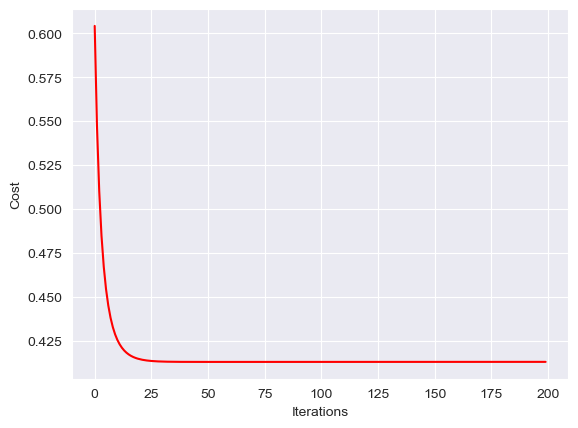

In [63]:
#Plotting the graph for Cost calculated
plt.plot(cost_plot3, color = "red")
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.show()

In [64]:
#Changing the predicted values into 1s & 0s
predictions3 = []
for i in pred_3:
    #1 - if greater than 0.5
    if i >= 0.5:
        predictions3.append(1)
    #2 - if lesser than 0.5
    else:
        predictions3.append(0)

In [65]:
#Printing the actual & predicted values
print(predictions3)
print(list(y_test))


[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
[1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1]


In [66]:
#Evaluating the performance using confusion matrix
TP_3, TN_3, FP_3, FN_3, confusion_matrix_3 = calculate_cm(predictions3, y_test)
precision_3, recall_3, f1_score_3, accuracy_3 = performance_eval(TP_3, TN_3, FP_3, FN_3)

In [67]:
#Printing the values
print_(TP_3, TN_3, FP_3, FN_3, confusion_matrix_3, precision_3, recall_3, f1_score_3, accuracy_3)

True Positive =  35 
True Negative =  0 
False Positive =  5 
False Negative =  0 


Confusion Matrix [[TN, FP],[FN, TP]] =  [[0, 5], [0, 35]]


Precision =  0.875 
Recall =  1.0 
F1 Score =  0.9333333333333333 
Accuracy =  0.875


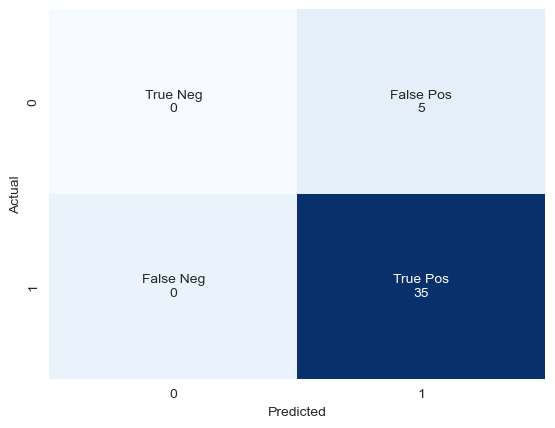

In [68]:
#Plotting confusion matrix
group_names = ['True Neg', 'False Pos', 'False Neg', 'True Pos']

# Format the values in the confusion matrix as strings
group_counts = [f"{value}" for row in confusion_matrix_3 for value in row]

# Create labels that combine group_names and group_counts
labels = [f'{name}\n{count}' for name, count in zip(group_names, group_counts)]

labels = np.array(labels).reshape(2, 2)

fig, ax = plt.subplots()
heatmap = sns.heatmap(confusion_matrix, annot=labels, fmt='', cmap='Blues', cbar=False)

# Add labels for the x and y axes
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [69]:
#Printing the  values from the best model from 3b
print("\nFull model built using forward selection in 3b:\n")
print("\nConfusion matrix5/: [[0, 0], [5, 35]]\n\nPrecision = 1.0\nRecall = 0.875\nF1_score = 0.9333333333333333\nAccuracy = 0.875\nFeatures: Mean Texture")


Full model built using forward selection in 3b:


Confusion matrix5/: [[0, 0], [5, 35]]

Precision = 1.0
Recall = 0.875
F1_score = 0.9333333333333333
Accuracy = 0.875
Features: Mean Texture


#### Based on the above results, we can clearly say that feature scaling improves the results.

#### b. Cost Function:

#### I. Keeping the best model after the experiments from Q.4a, design a Logistic Regression model to predict breast cancer recurrence (Outcome) by changing the cost function to the following (Mean Squared Error)

In [70]:
#Initializing the input variable
features_1 = ['Mean Texture']
x = df[features_1]
x

,Mean Texture
0,27.60
1,10.38
2,17.44
3,20.38
4,14.34
...,...
193,21.92
194,31.18
195,29.19
196,22.84


In [71]:
#Feature Scaling
x = (x - x.mean()) / (x.std())
x.head()

,Mean Texture
0,1.238630
1,-2.767615
2,-1.125101
3,-0.441108
4,-1.846318


In [72]:
#Splitting the data into Training & Testing
x_train, y_train, x_test, y_test = df_split(df,0.8)

#Displaying the values
x_train, y_train, x_test, y_test 

(     Mean Texture
 0        1.238630
 1       -2.767615
 2       -1.125101
 3       -0.441108
 4       -1.846318
 ..            ...
 153      0.245211
 154     -0.643514
 155     -0.804043
 156     -0.482985
 157     -0.399231
 
 [158 rows x 1 columns],
 0      1
 1      1
 2      1
 3      1
 4      0
       ..
 153    1
 154    1
 155    0
 156    1
 157    0
 Name: Outcome, Length: 158, dtype: int64,
      Mean Texture
 158     -1.106489
 159     -0.241028
 160      0.515086
 161     -0.822655
 162      0.389455
 163     -0.745880
 164     -0.394578
 165     -0.469026
 166     -0.157274
 167      2.120376
 168      1.941235
 169      0.654677
 170      0.026520
 171      1.389853
 172      1.350302
 173      0.361537
 174      0.905939
 175      1.945888
 176      0.698880
 177      2.027316
 178      0.745410
 179      1.050183
 180     -1.204202
 181     -0.324783
 182      0.519739
 183      1.196753
 184      0.391781
 185      0.563943
 186      2.697350
 187      1.785359
 18

In [73]:
#Defining a function for the updated Cost Function
def cost_function_mse (x, y, w, c):
    m = len(x)
    pred = []
    
    # Calculate the predictions
    z = (np.dot(x,w) + c)
    pred = (sigmoid(z))  

    #Calculating the cost
    cost = (1/(2 * m)) * ((np.sum(pred - y))**2)

    return cost

In [74]:
#Calling the cost, gradient and sigmoig functions
num_iterations = 200
#Initialize the weights
n = x_train.shape[1]
w = np.zeros(n)
c = 0
cost_plot4 = []

#Loop for calling the functions over multiple iterations
for i in range (num_iterations):
    w,c = gradient_descent(x_train, y_train, w, c, l = 0.7)
    cost_old = cost_function(x_test, y_test, w, c)    
    cost_2 = cost_function_mse(x_test, y_test, w, c)
    cost_plot4.append(cost_2)
    pred_4 = (sigmoid(np.dot(x_test,w) + c))
    
#Printing the values
print ("w Values = ", w, "\n")
print ("c Value = ", c, "\n")
print("The Cost_MSE is = ", cost_2,"\n")
print ("The predicted Values are = \n", pred_4)

w Values =  [-0.00465592] 

c Value =  1.0151135370224025 

The Cost_MSE is =  0.4010533577408915 

The predicted Values are = 
 [0.73502427 0.73423872 0.73355121 0.7347668  0.73366552 0.73469714
 0.7343782  0.73444581 0.73416262 0.73208782 0.73225138 0.73342416
 0.73399558 0.7327544  0.73279046 0.73369092 0.73319537 0.73224713
 0.73338392 0.73217279 0.73334156 0.73306398 0.73511286 0.73431481
 0.73354697 0.73293042 0.7336634  0.73350675 0.7315606  0.73239364
 0.73217492 0.73440355 0.73293254 0.7329813  0.73338816 0.73409497
 0.73213243 0.73255496 0.73390039 0.73277985]


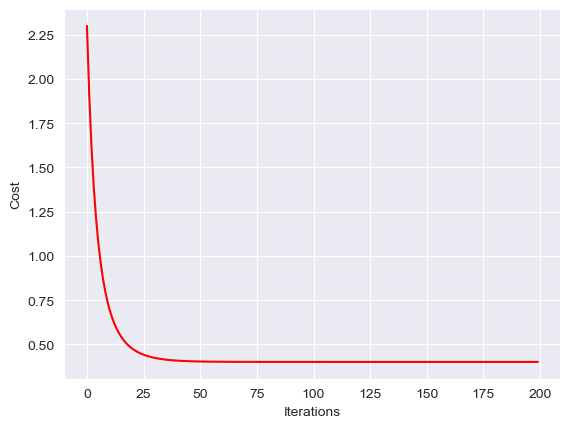

In [75]:
#Plotting the graph for cost over multiple iterations
plt.plot(cost_plot4, color = "red")
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.show()

In [76]:
#Changing predictions into 1s & 0s
predictions4 = []
for i in pred_4:
    #1 - if greater than or equals to 0.5
    if i >=0.5:
        predictions4.append(1)
    #0 - if lesser than to 0.5
    else:
        predictions4.append(0)

In [77]:
#Printing the predicted & actual values
print(predictions4)
print(list(y_test))


[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
[1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1]


In [78]:
#Evaluatig the performance
TP_4, TN_4, FP_4, FN_4, confusion_matrix_4 = calculate_cm(predictions4, y_test)
precision_4, recall_4, f1_score_4, accuracy_4 = performance_eval(TP_4, TN_4, FP_4, FN_4)

In [79]:
#Printing the performance values
print_(TP_4, TN_4, FP_4, FN_4, confusion_matrix_4, precision_4, recall_4, f1_score_4, accuracy_4)

True Positive =  35 
True Negative =  0 
False Positive =  5 
False Negative =  0 


Confusion Matrix [[TN, FP],[FN, TP]] =  [[0, 5], [0, 35]]


Precision =  0.875 
Recall =  1.0 
F1 Score =  0.9333333333333333 
Accuracy =  0.875


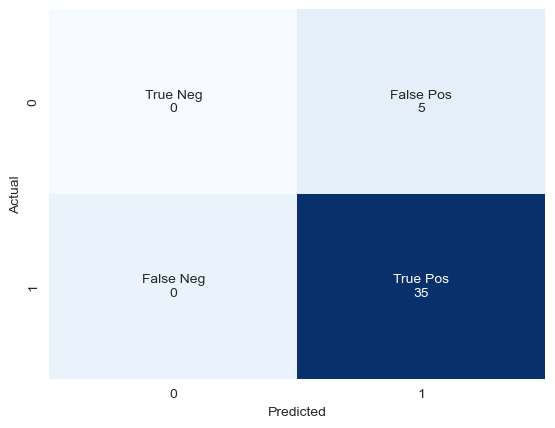

In [80]:
#Plotting the confusion matrix
group_names = ['True Neg', 'False Pos', 'False Neg', 'True Pos']

# Format the values in the confusion matrix as strings
group_counts = [f"{value}" for row in confusion_matrix_4 for value in row]

# Create labels that combine group_names and group_counts
labels = [f'{name}\n{count}' for name, count in zip(group_names, group_counts)]

labels = np.array(labels).reshape(2, 2)

fig, ax = plt.subplots()
heatmap = sns.heatmap(confusion_matrix, annot=labels, fmt='', cmap='Blues', cbar=False)

# Add labels for the x and y axes
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [81]:
#Printing the values for the best model from 3c
print("\nFull model built using forward selection in 3b:\n")
print("\nConfusion matrix: [[0, 0], [5, 35]]\n\nPrecision = 1.0\nRecall = 0.875\nF1_score = 0.9333333333333333\nAccuracy = 0.875\nFeatures: Mean Texture")


Full model built using forward selection in 3b:


Confusion matrix: [[0, 0], [5, 35]]

Precision = 1.0
Recall = 0.875
F1_score = 0.9333333333333333
Accuracy = 0.875
Features: Mean Texture


In [82]:
#Comparing the cost from logistic regression model vs cost from MSE
print("The Cost_MSE is = ", cost_2,"\n")
print("The Old Cost is = ", cost_old,"\n")


The Cost_MSE is =  0.4010533577408915 

The Old Cost is =  0.43675531495799036 



#### II. Compare the performance of both the models (4.b.i and 4.a.). Do they give the same solution with a difference in cost function

#### Based on the results above, there is a slight difference between the cost of logistic regression cost and the MSE value. All the other parameters are the same.